In [1]:
#Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="darkgrid")

In [2]:
# Load the two datasets
movies = pd.read_csv('../data/movies.csv')
ratings = pd.read_csv('../data/ratings.csv')

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


In [3]:
#Preview data
print("=== MOVIES ===")
print(movies.head())
print("\n=== RATINGS ===")
print(ratings.head())

=== MOVIES ===
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

=== RATINGS ===
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [4]:
print("=== RATINGS INFO ===")
print(ratings.describe())

print("\nUnique Users:", ratings['userId'].nunique())
print("Unique Movies:", ratings['movieId'].nunique())
print("Total Ratings:", len(ratings))

=== RATINGS INFO ===
              userId        movieId         rating     timestamp
count  100836.000000  100836.000000  100836.000000  1.008360e+05
mean      326.127564   19435.295718       3.501557  1.205946e+09
std       182.618491   35530.987199       1.042529  2.162610e+08
min         1.000000       1.000000       0.500000  8.281246e+08
25%       177.000000    1199.000000       3.000000  1.019124e+09
50%       325.000000    2991.000000       3.500000  1.186087e+09
75%       477.000000    8122.000000       4.000000  1.435994e+09
max       610.000000  193609.000000       5.000000  1.537799e+09

Unique Users: 610
Unique Movies: 9724
Total Ratings: 100836


C:\Users\ojash\AppData\Local\Temp\ipykernel_14032\72129221.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, palette='viridis')


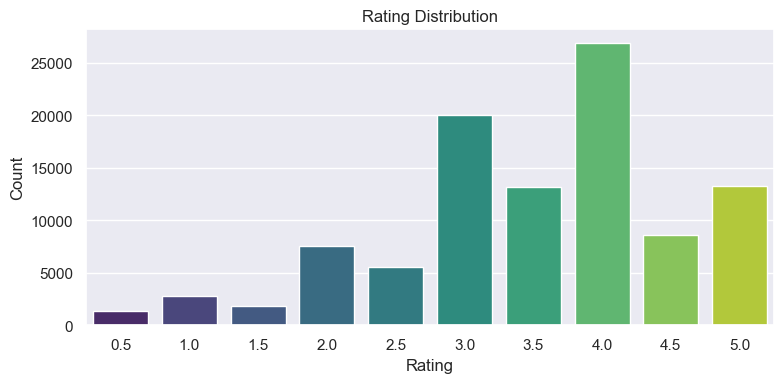

In [5]:
plt.figure(figsize=(8,4))
sns.countplot(x='rating', data=ratings, palette='viridis')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/rating_distribution.png')
plt.show()

In [6]:
#Top 10 Most Rated Movies
# Count how many times each movie was rated
rating_counts = ratings.groupby('movieId')['rating'].count().reset_index()
rating_counts.columns = ['movieId', 'rating_count']

# Merge with movie titles
popular_movies = rating_counts.merge(movies, on='movieId')

# Sort by most rated
top10 = popular_movies.sort_values('rating_count', ascending=False).head(10)

top10[['title', 'rating_count']]

,title,rating_count
314,Forrest Gump (1994),329
277,"Shawshank Redemption, The (1994)",317
257,Pulp Fiction (1994),307
510,"Silence of the Lambs, The (1991)",279
1938,"Matrix, The (1999)",278
224,Star Wars: Episode IV - A New Hope (1977),251
418,Jurassic Park (1993),238
97,Braveheart (1995),237
507,Terminator 2: Judgment Day (1991),224
461,Schindler's List (1993),220


In [7]:
#Top 10 Highest Rated Movies (with minimum 50 ratings)
# Average rating per movie
avg_ratings = ratings.groupby('movieId')['rating'].mean().reset_index()
avg_ratings.columns = ['movieId', 'avg_rating']

# Count ratings per movie
count_ratings = ratings.groupby('movieId')['rating'].count().reset_index()
count_ratings.columns = ['movieId', 'rating_count']

# Merge both
movie_stats = avg_ratings.merge(count_ratings, on='movieId').merge(movies, on='movieId')

# Filter: only movies with at least 50 ratings (removes obscure movies)
popular = movie_stats[movie_stats['rating_count'] >= 50]

# Top 10 by average rating
top_rated = popular.sort_values('avg_rating', ascending=False).head(10)
top_rated[['title', 'avg_rating', 'rating_count']]




,title,avg_rating,rating_count
277,"Shawshank Redemption, The (1994)",4.429022,317
659,"Godfather, The (1972)",4.289062,192
2224,Fight Club (1999),4.272936,218
974,Cool Hand Luke (1967),4.271930,57
602,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97
686,Rear Window (1954),4.261905,84
921,"Godfather: Part II, The (1974)",4.259690,129
6298,"Departed, The (2006)",4.252336,107
913,Goodfellas (1990),4.250000,126
694,Casablanca (1942),4.240000,100


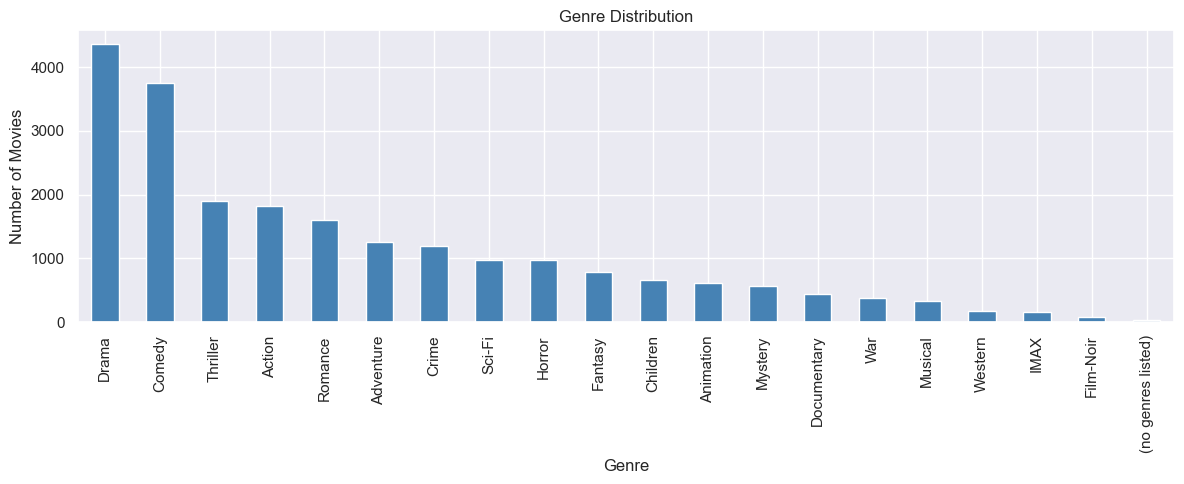

In [8]:
#Genre Distribution

# Genres are pipe-separated like "Action|Comedy|Drama"
# Split and explode them into individual rows
genre_series = movies['genres'].str.split('|').explode()

plt.figure(figsize=(12,5))
genre_series.value_counts().plot(kind='bar', color='steelblue')
plt.title('Genre Distribution')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('../data/genre_distribution.png')
plt.show()